In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph , START , END
from dotenv import load_dotenv 
import os
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

In [3]:
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

In [4]:
llm = ChatOpenAI(
    model="gpt-5-nano", temperature = 0) 

In [5]:
class MoodState (TypedDict):
    input_text: str
    sentiment: str
    response: str

In [6]:
def sentiment (state : MoodState) -> MoodState :
    """llm answer the user """
    system_promt = """Your are an sentiment classifier , 
    -the classes are 3 : sad or happy or neutral
    -from the user input reply by just one word : sad or happy or neutral 
    user input : {input}
    """
    messages = [
        SystemMessage(content=system_promt),
        HumanMessage(content=state['input_text'])
    ]
    # Invoke the model
    state['sentiment'] = llm.invoke(messages).content
    return state

In [7]:
def chatbot(state : MoodState) -> MoodState :
    """classify the mood seniment"""
    if state['sentiment'] == "sad": return "cheer_up_node"
    elif state['sentiment'] == "happy": return "celebrate_node"
    elif state['sentiment'] == "neutral": return "neutral_node"

In [8]:
def cheer_up_node (state : MoodState) -> MoodState :
    """cheer up the sad user"""
    system_promt = """the user sentiment is sad , sheer up with him/her
    user input : {input}
    """
    messages = [
        SystemMessage(content=system_promt),
        HumanMessage(content=state['input_text'])
    ]
    
    state['response'] = llm.invoke(messages).content
    return state

def celebrate_node(state : MoodState) -> MoodState :
    """celebrate with the happy"""
    system_promt = """the user sentiment is happy , celebrate  with him/her
    user input : {input}
    """
    messages = [
        SystemMessage(content=system_promt),
        HumanMessage(content=state['input_text'])
    ]
    
    state['response'] = llm.invoke(messages).content
    return state

def neutral_node(state : MoodState) -> MoodState :
    """neutral with the user"""
    system_promt = """the user sentiment is neutral , be neutral  with him/her
    user input : {input}
    """
    messages = [
        SystemMessage(content=system_promt),
        HumanMessage(content=state['input_text'])
    ]
    
    state['response'] = llm.invoke(messages).content
    return state

In [9]:
graph = StateGraph(MoodState)

graph.add_node("sentiment",sentiment)
graph.add_edge(START, "sentiment")
graph.add_node("cheer_up_node",cheer_up_node)
graph.add_node("celebrate_node",celebrate_node)
graph.add_node("neutral_node",neutral_node)

graph.add_node("router", lambda state:state)


graph.add_edge("sentiment","router") 

graph.add_conditional_edges(
    "router",
    chatbot,
    {
        "cheer_up_node":"cheer_up_node",
        "celebrate_node":"celebrate_node",
        "neutral_node":"neutral_node"

    }
)
graph.add_edge("cheer_up_node", END) 
graph.add_edge("celebrate_node", END) 
graph.add_edge("neutral_node", END) 

app = graph.compile()

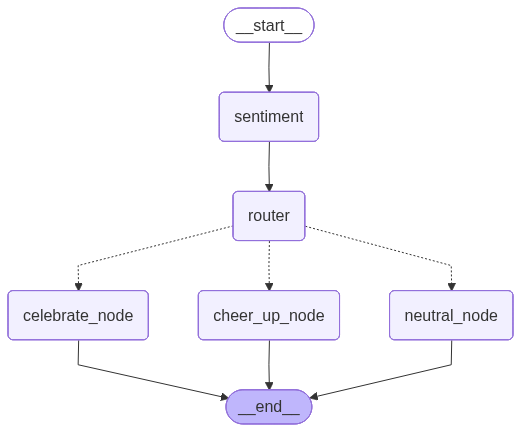

In [10]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
reslt1 = app.invoke({"input_text":"I passed my exam!"})

In [12]:
reslt1

{'input_text': 'I passed my exam!',
 'sentiment': 'happy',
 'response': 'That’s fantastic—congratulations! You must be so thrilled. What exam was it? Do you have any plans to celebrate? If you’d like, I can help brainstorm a quick celebration or plan your next steps after this win. You did amazing! 🎉'}

In [13]:
reslt2 = app.invoke({"input_text":"I failed my exam.!"})

In [14]:
reslt2

{'input_text': 'I failed my exam.!',
 'sentiment': 'sad',
 'response': 'I’m really sorry you’re dealing with this. Failing an exam hurts, but it doesn’t define you or your future. You can bounce back from this.\n\nHere are some quick steps to move forward:\n- Take a moment to breathe and acknowledge the disappointment. Then switch to a plan.\n- Review the exam: which topics were hardest? which questions did you miss and why (concepts, wording, time, carelessness)?\n- Check retake or remediation options: talk to your teacher/professor about retakes, extra credit, or feedback you can use.\n- Build a focused plan: pick 3-4 weak areas and schedule focused practice for the next 2–4 weeks. Include timed practice to improve pace.\n- Use effective study methods: active recall, spaced repetition, practice with past papers, and teaching concepts to someone else.\n- Get support: ask a teacher, tutor, or study group for help. If you’d like, I can help you draft a study plan or work through a tough

In [15]:
reslt3 = app.invoke({"input_text":"The exam is tomorrow."})

In [16]:
reslt3

{'input_text': 'The exam is tomorrow.',
 'sentiment': 'neutral',
 'response': 'Got it. Here’s a practical last-minute plan you can use for an exam tomorrow.\n\nTonight\n- Confirm details: format (multiple choice, short answer, essay), allowed materials, and which topics are likely covered.\n- Prioritize 5–7 high-yield topics: skim your notes or a syllabus, and pick the core ideas or formulas you know best.\n- Quick review: focus on understanding concepts, not re-reading everything. Use a one-page summary or concept map.\n- Practice: do 10–15 short practice questions or past paper items if you have them. Time yourself to build speed.\n- “Cheat sheet” (if allowed): write a clear, compact sheet with formulas, key definitions, and problem-solving steps. Even if you can’t use it, the process helps memory.\n- Pack now: pencil case, calculator, IDs, water, snacks, and any permitted materials.\n\nSleep and routine\n- Try to get as much sleep as possible. If you can’t sleep well, prioritize a s